<a href="https://colab.research.google.com/github/abdullaawad/Data-Warehousing-Coursework/blob/main/DWCoursework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Task A
!pip install --upgrade yfinance requests urllib3


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 51.5 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: curl_cffi
    Found existing installation: curl_cffi 0.14.0
    Uninstalling curl_cffi-0.14.0:
      Successfully uninstalled curl_cffi-0.14.0
  Attempting uninstall: yfinance
    Found existing installation: yfinance 0.2.66
    Uninstalling yfinance-0.2.66:
      Successfully uninstalled yfinance-0.2.66
ERROR: pip's dependency resolver d

In [ ]:
#Install Package
!pip install yfinance
!pip install yahoofinancials


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.9/51.9 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for yahoofinancials: filename=yahoofinancials-1.20-py3-none-any.whl size=38618 sha256=22a5ac978e5d07cf9006f97b7e28aa7bd4b18b88a9211403b124f32c520eb977
  Stored in directory: /root/.cache/pip/wheels/b0/e1/ca/e683b02e57db550881c8ebb89ba3eccb7a5c0ebfad7f03acea
Successfully built yahoofinancials


In [ ]:
import pandas as pd
import yfinance as yf
import requests
from io import StringIO
from IPython.display import display
import yfinance as yf
from yahoofinancials import YahooFinancials
from datetime import datetime
from typing import dataclass_transform
import numpy as np

In [ ]:
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {"User-Agent": "Mozilla/5.0"}

In [ ]:
response = requests.get(url, headers=headers)
response.raise_for_status()

# Read all tables on the page
tables = pd.read_html(StringIO(response.text))

# Find the table that contains a 'Symbol' column
sp500_table = None
for table in tables:
    cols_lower = [str(c).lower() for c in table.columns]
    if "symbol" in cols_lower:
        sp500_table = table.copy()
        break

if sp500_table is None:
    raise ValueError("No table with a 'Symbol' column found on the page.")

# Standardise column name to 'Symbol'
for col in sp500_table.columns:
    if str(col).lower() == "symbol":
        symbol_col = col
        break

sp500_table.rename(columns={symbol_col: "Symbol"}, inplace=True)

# Clean tickers (BRK.B → BRK-B) for Yahoo Finance
sp500_table["Symbol"] = (
    sp500_table["Symbol"]
    .astype(str)
    .str.replace(".", "-", regex=False)
)

# FINAL LIST OF TICKERS
tickers = sp500_table["Symbol"].unique().tolist()

print("Number of tickers:", len(tickers))
display(sp500_table.head())


Number of tickers: 503


,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


In [ ]:
# Define a start date and End Date
start = '2022-01-01'
#setting End Date
end = '2025-01-01'
data_source='yahoo'
p = yf.download(tickers, start, end)

[***************       32%                       ]  161 of 503 completedERROR:yfinance:$Q: possibly delisted; no price data found  (1d 2022-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1641013200, endDate = 1735707600")
[**********************49%                       ]  248 of 503 completedERROR:yfinance:$SNDK: possibly delisted; no price data found  (1d 2022-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1641013200, endDate = 1735707600")
[*********************100%***********************]  503 of 503 completed
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['Q', 'SNDK']: possibly delisted; no price data found  (1d 2022-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1641013200, endDate = 1735707600")


In [ ]:
tickers

['MMM',
 'AOS',
 'ABT',
 'ABBV',
 'ACN',
 'ADBE',
 'AMD',
 'AES',
 'AFL',
 'A',
 'APD',
 'ABNB',
 'AKAM',
 'ALB',
 'ARE',
 'ALGN',
 'ALLE',
 'LNT',
 'ALL',
 'GOOGL',
 'GOOG',
 'MO',
 'AMZN',
 'AMCR',
 'AEE',
 'AEP',
 'AXP',
 'AIG',
 'AMT',
 'AWK',
 'AMP',
 'AME',
 'AMGN',
 'APH',
 'ADI',
 'AON',
 'APA',
 'APO',
 'AAPL',
 'AMAT',
 'APP',
 'APTV',
 'ACGL',
 'ADM',
 'ARES',
 'ANET',
 'AJG',
 'AIZ',
 'T',
 'ATO',
 'ADSK',
 'ADP',
 'AZO',
 'AVB',
 'AVY',
 'AXON',
 'BKR',
 'BALL',
 'BAC',
 'BAX',
 'BDX',
 'BRK-B',
 'BBY',
 'TECH',
 'BIIB',
 'BLK',
 'BX',
 'XYZ',
 'BK',
 'BA',
 'BKNG',
 'BSX',
 'BMY',
 'AVGO',
 'BR',
 'BRO',
 'BF-B',
 'BLDR',
 'BG',
 'BXP',
 'CHRW',
 'CDNS',
 'CPT',
 'CPB',
 'COF',
 'CAH',
 'CCL',
 'CARR',
 'CVNA',
 'CASY',
 'CAT',
 'CBOE',
 'CBRE',
 'CDW',
 'COR',
 'CNC',
 'CNP',
 'CF',
 'CRL',
 'SCHW',
 'CHTR',
 'CVX',
 'CMG',
 'CB',
 'CHD',
 'CIEN',
 'CI',
 'CINF',
 'CTAS',
 'CSCO',
 'C',
 'CFG',
 'CLX',
 'CME',
 'CMS',
 'KO',
 'CTSH',
 'COHR',
 'COIN',
 'CL',
 'CMCSA',
 '

In [ ]:
p

Price      Adj Close            Close                                      \
Ticker             Q SNDK           A        AAPL        ABBV        ABNB   
Date                                                                        
2022-01-03       NaN  NaN  151.702133  178.103668  115.847206  172.679993   
2022-01-04       NaN  NaN  146.573669  175.843231  115.624794  170.800003   
2022-01-05       NaN  NaN  144.062744  171.165802  116.232185  162.250000   
2022-01-06       NaN  NaN  144.566879  168.308502  115.684677  159.750000   
2022-01-07       NaN  NaN  140.718063  168.474838  115.385292  166.050003   
...              ...  ...         ...         ...         ...         ...   
2024-12-24       NaN  NaN  134.457275  256.797211  172.530670  134.990005   
2024-12-26       NaN  NaN  134.190506  257.612732  171.763855  135.320007   
2024-12-27       NaN  NaN  133.904007  254.201355  170.623245  133.384995   
2024-12-30       NaN  NaN  132.797516  250.829788  168.888351  131.809998   
2024-12-31       NaN  NaN  132.963806  249.059479  170.326096  131.410004   

Price                                                      ...   Volume  \
Ticker             ABT       ACGL         ACN        ADBE  ...       WY   
Date                                                       ...            
2022-01-03  128.345963  42.362530  383.711945  564.369995  ...  3831100   
2022-01-04  125.327522  42.914051  380.969879  554.000000  ...  3089700   
2022-01-05  124.764420  42.410072  374.260651  514.429993  ...  3737600   
2022-01-06  124.745979  42.657307  356.187500  514.119995  ...  3315200   
2022-01-07  125.133652  42.856995  349.355835  510.700012  ...  3309900   
...                ...        ...         ...         ...  ...      ...   
2024-12-24  112.058289  92.669998  356.539642  447.940002  ...  1780100   
2024-12-26  112.556274  92.930000  355.356506  450.160004  ...  1736500   
2024-12-27  112.282867  92.339996  351.166321  446.480011  ...  2320500   
2024-12-30  110.144447  91.889999  347.528259  445.799988  ...  2914700   
2024-12-31  110.447136  92.349998  346.838165  444.679993  ...  3125200   

Price                                                                        \
Ticker         WYNN      XEL       XOM      XYL       XYZ      YUM      ZBH   
Date                                                                          
2022-01-03  2437800  3501100  24282400   759100   7315700  1251400  1184809   
2022-01-04  2292300  4197000  38584000   925400  14768500   935900  1400800   
2022-01-05  3439900  4166000  34033300  1090200  17546200   977900  1895715   
2022-01-06  2583200  2296000  30668500   703400  16244200   862400  1088813   
2022-01-07  1720400  2673100  23985400   765000   9426000   833700  1690230   
...             ...      ...       ...      ...       ...      ...      ...   
2024-12-24   692800   943900   7807000   379300   2197700   533000   458600   
2024-12-26  1218900  1394900   9652400   575700   2991100  1040900  1277300   
2024-12-27  1086700  2015000  11943900   552400   4140800  1146300   743400   
2024-12-30  2180100  2642900  11080800   586800   5383800  1144600  1532000   
2024-12-31  1612600  2143800  12387800   641600   4989400  1217100   683300   

Price                        
Ticker        ZBRA      ZTS  
Date                         
2022-01-03  272600  2772700  
2022-01-04  346000  4664000  
2022-01-05  403700  4749400  
2022-01-06  338300  3103400  
2022-01-07  432800  2206500  
...            ...      ...  
2024-12-24   88700  1023600  
2024-12-26  140100  2167200  
2024-12-27  287200  1800100  
2024-12-30  211300  1531400  
2024-12-31  327900  1327400  

[753 rows x 2517 columns]

In [ ]:
data = p

In [ ]:
data = p['Close']
data

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,151.702133,178.103668,115.847206,172.679993,128.345963,42.362530,383.711945,564.369995,164.526474,60.037281,...,33.979374,85.125786,59.164787,54.760242,110.957474,164.029999,125.887215,120.797729,583.900024,224.021225
2022-01-04,146.573669,175.843231,115.624794,170.800003,125.327522,42.914051,380.969879,554.000000,163.040497,61.151531,...,34.414906,84.854218,59.539257,56.819988,112.134537,156.330002,126.560333,122.023201,587.599976,215.492294
2022-01-05,144.062744,171.165802,116.232185,162.250000,124.764420,42.410072,374.260651,514.429993,160.523590,60.673981,...,33.560612,81.711823,60.122707,57.526699,110.606262,143.490005,124.955940,121.620934,558.179993,207.298401
2022-01-06,144.566879,168.308502,115.684677,159.750000,124.745979,42.657307,356.187500,514.119995,161.034409,61.213432,...,33.828617,82.090080,59.652462,58.879742,110.454369,144.660004,126.246819,120.610626,555.159973,208.121567
2022-01-07,140.718063,168.474838,115.385292,166.050003,125.133652,42.856995,349.355835,510.700012,156.808655,61.735195,...,33.786751,82.002800,60.174953,59.362370,109.571587,141.539993,124.799217,119.880966,530.859985,202.062332
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,134.457275,256.797211,172.530670,134.990005,112.058289,92.669998,356.539642,447.940002,213.882050,48.364086,...,27.116615,87.733513,65.030991,101.953667,116.360298,91.080002,131.828506,105.724739,395.440002,161.848892
2024-12-26,134.190506,257.612732,171.763855,135.320007,112.556274,92.930000,355.356506,450.160004,213.852631,48.344978,...,27.030256,88.257271,65.002380,102.039902,116.675446,91.480003,132.805023,105.675476,396.850006,162.654709
2024-12-27,133.904007,254.201355,170.623245,133.384995,112.282867,92.339996,351.166321,446.480011,212.803284,48.316322,...,26.857538,87.634682,64.964249,102.030319,115.749695,88.970001,132.053116,105.301064,389.070007,161.750641


In [ ]:
data.dropna(axis=1, how='all')

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,151.702133,178.103668,115.847206,172.679993,128.345963,42.362530,383.711945,564.369995,164.526474,60.037281,...,33.979374,85.125786,59.164787,54.760242,110.957474,164.029999,125.887215,120.797729,583.900024,224.021225
2022-01-04,146.573669,175.843231,115.624794,170.800003,125.327522,42.914051,380.969879,554.000000,163.040497,61.151531,...,34.414906,84.854218,59.539257,56.819988,112.134537,156.330002,126.560333,122.023201,587.599976,215.492294
2022-01-05,144.062744,171.165802,116.232185,162.250000,124.764420,42.410072,374.260651,514.429993,160.523590,60.673981,...,33.560612,81.711823,60.122707,57.526699,110.606262,143.490005,124.955940,121.620934,558.179993,207.298401
2022-01-06,144.566879,168.308502,115.684677,159.750000,124.745979,42.657307,356.187500,514.119995,161.034409,61.213432,...,33.828617,82.090080,59.652462,58.879742,110.454369,144.660004,126.246819,120.610626,555.159973,208.121567
2022-01-07,140.718063,168.474838,115.385292,166.050003,125.133652,42.856995,349.355835,510.700012,156.808655,61.735195,...,33.786751,82.002800,60.174953,59.362370,109.571587,141.539993,124.799217,119.880966,530.859985,202.062332
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,134.457275,256.797211,172.530670,134.990005,112.058289,92.669998,356.539642,447.940002,213.882050,48.364086,...,27.116615,87.733513,65.030991,101.953667,116.360298,91.080002,131.828506,105.724739,395.440002,161.848892
2024-12-26,134.190506,257.612732,171.763855,135.320007,112.556274,92.930000,355.356506,450.160004,213.852631,48.344978,...,27.030256,88.257271,65.002380,102.039902,116.675446,91.480003,132.805023,105.675476,396.850006,162.654709
2024-12-27,133.904007,254.201355,170.623245,133.384995,112.282867,92.339996,351.166321,446.480011,212.803284,48.316322,...,26.857538,87.634682,64.964249,102.030319,115.749695,88.970001,132.053116,105.301064,389.070007,161.750641


In [ ]:
data.head(10)

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,151.702133,178.103668,115.847206,172.679993,128.345963,42.362530,383.711945,564.369995,164.526474,60.037281,...,33.979374,85.125786,59.164787,54.760242,110.957474,164.029999,125.887215,120.797729,583.900024,224.021225
2022-01-04,146.573669,175.843231,115.624794,170.800003,125.327522,42.914051,380.969879,554.000000,163.040497,61.151531,...,34.414906,84.854218,59.539257,56.819988,112.134537,156.330002,126.560333,122.023201,587.599976,215.492294
2022-01-05,144.062744,171.165802,116.232185,162.250000,124.764420,42.410072,374.260651,514.429993,160.523590,60.673981,...,33.560612,81.711823,60.122707,57.526699,110.606262,143.490005,124.955940,121.620934,558.179993,207.298401
2022-01-06,144.566879,168.308502,115.684677,159.750000,124.745979,42.657307,356.187500,514.119995,161.034409,61.213432,...,33.828617,82.090080,59.652462,58.879742,110.454369,144.660004,126.246819,120.610626,555.159973,208.121567
2022-01-07,140.718063,168.474838,115.385292,166.050003,125.133652,42.856995,349.355835,510.700012,156.808655,61.735195,...,33.786751,82.002800,60.174953,59.362370,109.571587,141.539993,124.799217,119.880966,530.859985,202.062332
2022-01-10,140.727753,168.494415,116.677010,160.710007,124.856720,43.760349,351.476044,525.830017,158.257462,61.841293,...,33.627613,79.694489,60.836796,59.009026,108.460968,144.479996,123.056541,118.711617,535.409973,203.507721
2022-01-11,142.162613,171.322433,117.173195,168.610001,125.262871,44.093163,353.464294,529.890015,161.257294,62.327682,...,34.113388,82.730202,59.739532,61.491066,110.293015,148.429993,120.474792,120.096123,538.570007,203.699173
2022-01-12,144.944931,171.762711,117.446938,169.539993,123.435188,44.188255,356.345764,532.369995,161.368774,62.274612,...,34.381416,83.215134,59.730846,61.310085,110.283524,145.470001,119.082504,117.476791,538.440002,203.708755
2022-01-13,140.737473,168.494415,115.407112,166.000000,120.100311,44.445000,341.399963,516.900024,157.681641,62.699100,...,34.892319,81.692444,60.105297,60.870560,108.612846,136.949997,118.769020,119.806122,525.799988,198.147263


In [ ]:
#daily returns
daily_returns = data.pct_change()
daily_returns = daily_returns.iloc[1:]
daily_returns

/tmp/ipykernel_5724/3241600668.py:2: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  daily_returns = data.pct_change()


Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-04,-0.033806,-0.012692,-0.001920,-0.010887,-0.023518,0.013019,-0.007146,-0.018374,-0.009032,0.018559,...,0.012818,-0.003190,0.006329,0.037614,0.010608,-0.046943,0.005347,0.010145,0.006337,-0.038072
2022-01-05,-0.017131,-0.026600,0.005253,-0.050059,-0.004493,-0.011744,-0.017611,-0.071426,-0.015437,-0.007809,...,-0.024823,-0.037033,0.009799,0.012438,-0.013629,-0.082134,-0.012677,-0.003297,-0.050068,-0.038024
2022-01-06,0.003499,-0.016693,-0.004710,-0.015408,-0.000148,0.005830,-0.048290,-0.000603,0.003182,0.008891,...,0.007986,0.004629,-0.007821,0.023520,-0.001373,0.008154,0.010331,-0.008307,-0.005410,0.003971
2022-01-07,-0.026623,0.000988,-0.002588,0.039437,0.003108,0.004681,-0.019180,-0.006652,-0.026241,0.008524,...,-0.001238,-0.001063,0.008759,0.008197,-0.007992,-0.021568,-0.011466,-0.006050,-0.043771,-0.029114
2022-01-10,0.000069,0.000116,0.011195,-0.032159,-0.002213,0.021078,0.006069,0.029626,0.009239,0.001719,...,-0.004710,-0.028149,0.010999,-0.005952,-0.010136,0.020772,-0.013964,-0.009754,0.008571,0.007153
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,0.011144,0.011478,0.009025,0.003494,0.003937,0.006298,0.007972,0.002686,0.014891,0.004364,...,0.006410,0.007604,0.007236,0.000941,0.005446,0.020047,0.008516,0.004494,0.012262,0.002557
2024-12-26,-0.001984,0.003176,-0.004445,0.002445,0.004444,0.002806,-0.003318,0.004956,-0.000138,-0.000395,...,-0.003185,0.005970,-0.000440,0.000846,0.002708,0.004392,0.007407,-0.000466,0.003566,0.004979
2024-12-27,-0.002135,-0.013242,-0.006641,-0.014300,-0.002429,-0.006349,-0.011791,-0.008175,-0.004907,-0.000593,...,-0.006390,-0.007054,-0.000587,-0.000094,-0.007934,-0.027438,-0.005662,-0.003543,-0.019604,-0.005558


In [ ]:
#beta =(correlation of stock's returns and index's returns) * (stock's standard dev of returns/index's sd of returns)
#download index data

sp500_index = yf.download('^GSPC', start, end)
all_tickers = tickers + ['^GSPC']
p = yf.download(all_tickers, start=start, end=end)['Close']
# The 'return p' line is likely a remnant or intended for a function.
# If you just want to display 'p', you can remove 'return' or implicitly display it.
p

[*********************100%***********************]  1 of 1 completed
[***************       32%                       ]  161 of 504 completedERROR:yfinance:$Q: possibly delisted; no price data found  (1d 2022-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1641013200, endDate = 1735707600")
[**********************49%                       ]  249 of 504 completedERROR:yfinance:$SNDK: possibly delisted; no price data found  (1d 2022-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1641013200, endDate = 1735707600")
[*********************100%***********************]  504 of 504 completed
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['Q', 'SNDK']: possibly delisted; no price data found  (1d 2022-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1641013200, endDate = 1735707600")


Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS,^GSPC
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,151.702133,178.103668,115.847198,172.679993,128.345978,42.362530,383.711945,564.369995,164.526474,60.037262,...,85.125763,59.164783,54.760239,110.957474,164.029999,125.887222,120.797737,583.900024,224.021240,4796.560059
2022-01-04,146.573685,175.843246,115.624802,170.800003,125.327492,42.914051,380.969849,554.000000,163.040451,61.151524,...,84.854210,59.539253,56.819996,112.134552,156.330002,126.560303,122.023193,587.599976,215.492249,4793.540039
2022-01-05,144.062759,171.165817,116.232170,162.250000,124.764420,42.410072,374.260712,514.429993,160.523605,60.673996,...,81.711823,60.122711,57.526691,110.606262,143.490005,124.955940,121.620949,558.179993,207.298370,4700.580078
2022-01-06,144.566879,168.308487,115.684669,159.750000,124.745964,42.657307,356.187500,514.119995,161.034363,61.213425,...,82.090080,59.652458,58.879753,110.454391,144.660004,126.246819,120.610634,555.159973,208.121597,4696.049805
2022-01-07,140.718048,168.474869,115.385262,166.050003,125.133652,42.856995,349.355865,510.700012,156.808624,61.735188,...,82.002785,60.174957,59.362362,109.571587,141.539993,124.799187,119.880966,530.859985,202.062317,4677.029785
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,134.457275,256.797211,172.530670,134.990005,112.058296,92.669998,356.539642,447.940002,213.882050,48.364086,...,87.733505,65.030975,101.953667,116.360306,91.080002,131.828506,105.724754,395.440002,161.848907,6040.040039
2024-12-26,134.190506,257.612732,171.763870,135.320007,112.556290,92.930000,355.356506,450.160004,213.852615,48.344978,...,88.257256,65.002380,102.039902,116.675446,91.480003,132.805023,105.675476,396.850006,162.654724,6037.589844
2024-12-27,133.904007,254.201370,170.623245,133.384995,112.282875,92.339996,351.166321,446.480011,212.803284,48.316322,...,87.634689,64.964249,102.030327,115.749695,88.970001,132.053085,105.301056,389.070007,161.750641,5970.839844


In [ ]:
def calculate_ratios(returns, benchmark_returns, risk_free_rate=0.04/252):
    excess = returns - risk_free_rate
    downside = excess[excess < 0]

    beta = np.cov(returns, benchmark_returns)[0,1] / np.var(benchmark_returns)
    return beta

In [ ]:
def build_screener(tickers, index='^GSPC', period='1y', risk_free_rate=0.04/252):
    p = fetch_data(tickers, index=index, period=period)
    benchmark = df[index].pct_change().dropna()
    results = []

    for ticker in tickers:
        ret = df[ticker].pct_change().dropna()
        aligned = pd.concat([ret, benchmark], axis=1, join='inner').dropna()
        beta = calculate_ratios(aligned[ticker], aligned[index], risk_free_rate)
        results.append({'Ticker': ticker, 'Beta': beta})

    return pd.DataFrame(results).sort_values('Beta', ascending=False)

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf

def calculate_ratios(returns, benchmark_returns, risk_free_rate=0.04/252):
    excess = returns - risk_free_rate
    downside = excess[excess < 0]

    # Handle cases where standard deviation or variance might be zero
    if np.var(benchmark_returns) == 0:
        beta = np.nan
    else:
        beta = np.cov(returns, benchmark_returns)[0,1] / np.var(benchmark_returns)

    return beta

# Redefine build_screener function (previously defined in EZK4mXjP2n8N, but that cell was deleted)
def build_screener(data_df, benchmark_ticker_symbol, risk_free_rate=0.04/252):
    # Calculate benchmark returns
    benchmark_returns = data_df[benchmark_ticker_symbol].pct_change().dropna()
    results = []

    # Iterate through all tickers in the data_df, excluding the benchmark ticker itself
    for ticker in data_df.columns:
        if ticker == benchmark_ticker_symbol:
            continue

        # Calculate individual ticker returns
        ticker_returns = data_df[ticker].pct_change().dropna()

        # Align the ticker returns and benchmark returns based on common dates
        aligned = pd.concat([ticker_returns, benchmark_returns], axis=1, join='inner').dropna()

        # Ensure that both series are not empty before proceeding to calculate ratios
        if not aligned.empty:
            # The column names in 'aligned' will be the original ticker and benchmark_ticker_symbol
            beta = calculate_ratios(aligned[ticker], aligned[benchmark_ticker_symbol], risk_free_rate)
            results.append({'Ticker': ticker, 'Beta': beta})
        else:
            results.append({'Ticker': ticker, 'Beta': np.nan})

    return pd.DataFrame(results).sort_values('Beta', ascending=False)


# 'p' is the DataFrame containing all the stock prices and the benchmark ('^GSPC')
# from the previous step (FhPfR9tP76xG).
benchmark_ticker = '^GSPC'
df = build_screener(p, benchmark_ticker, risk_free_rate=0.04/252)
print(df)


/tmp/ipykernel_5724/4108521710.py:29: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ticker_returns = data_df[ticker].pct_change().dropna()
/tmp/ipykernel_5724/4108521710.py:29: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ticker_returns = data_df[ticker].pct_change().dropna()


    Ticker      Beta
126   CVNA  3.298454
106   COIN  2.964902
498    XYZ  2.548173
340   NVDA  2.271536
39     APP  2.264945
..     ...       ...
405    SJM  0.196850
112    CPB  0.133844
208    GIS  0.133426
384      Q       NaN
409   SNDK       NaN

[503 rows x 2 columns]


In [ ]:
df[['Ticker', 'Beta']]

,Ticker,Beta
126,CVNA,3.298454
106,COIN,2.964902
498,XYZ,2.548173
340,NVDA,2.271536
39,APP,2.264945
...,...,...
405,SJM,0.196850
112,CPB,0.133844
208,GIS,0.133426
384,Q,NaN


In [ ]:
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
df

,Ticker,Beta
0,CVNA,3.298454
1,COIN,2.964902
2,XYZ,2.548173
3,NVDA,2.271536
4,APP,2.264945
...,...,...
496,LMT,0.244190
497,HRL,0.236923
498,SJM,0.196850
499,CPB,0.133844


In [ ]:
import statistics
Annual_vol = daily_returns.std() * np.sqrt(252)
Annual_vol

,0
Ticker,
A,0.296259
AAPL,0.270935
ABBV,0.219958
ABNB,0.467875
ABT,0.217839
...,...
XYZ,0.653825
YUM,0.191335
ZBH,0.245157


In [ ]:
df_top100 = df.iloc[:100]

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns

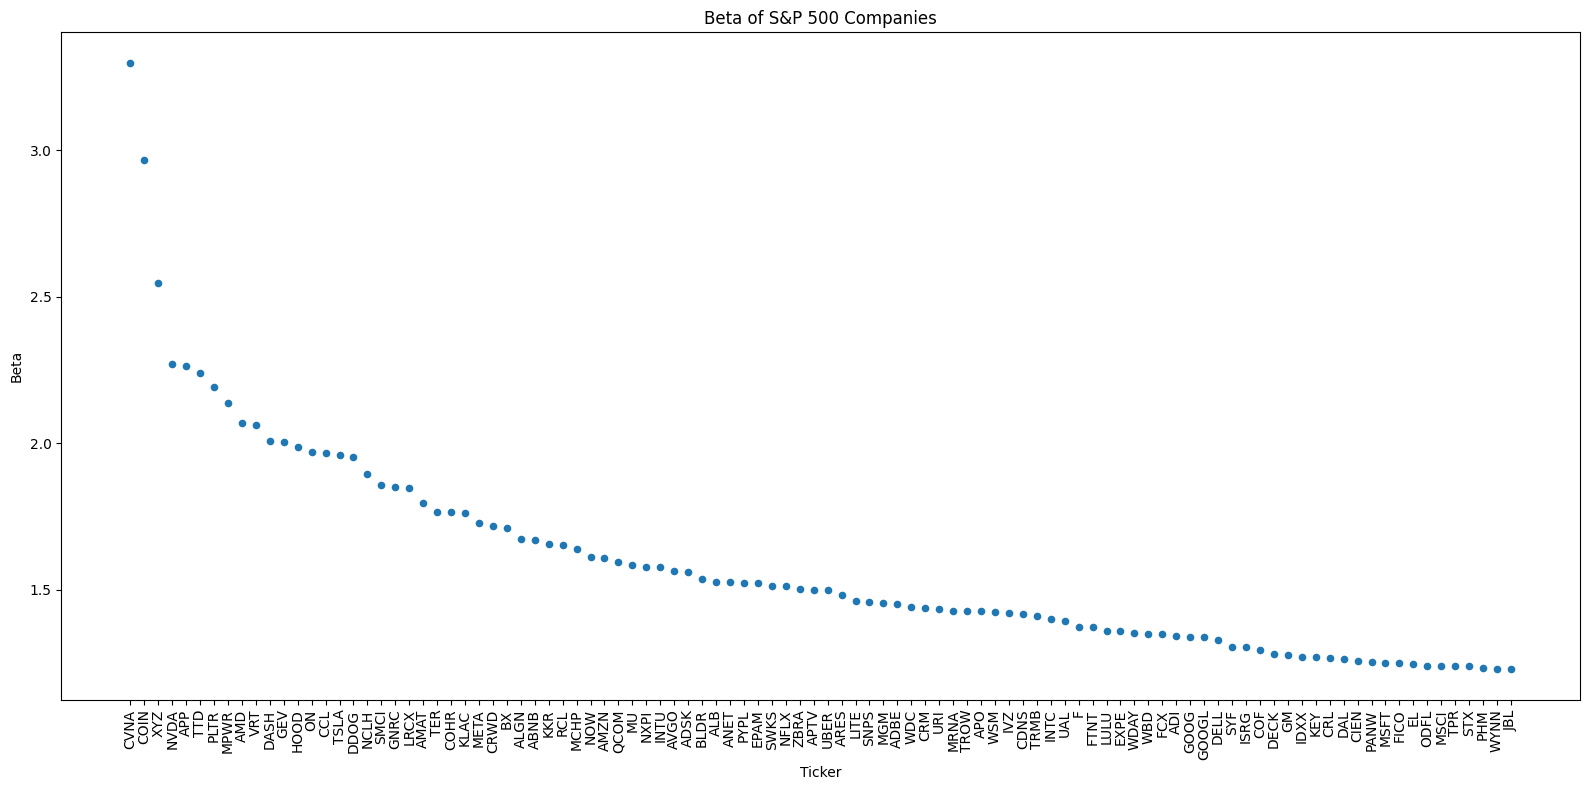

In [ ]:
df_top100.plot(x='Ticker', y='Beta', kind='scatter', figsize=(16,8))
plt.title('Beta of S&P 500 Companies')
plt.xlabel('Ticker')
plt.ylabel('Beta')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px

In [ ]:
px.scatter(df_top100, df_top100['Ticker'], y=df_top100['Beta'])

## **Part B: Customer Segmentation:**

<function matplotlib.pyplot.show(close=None, block=None)>

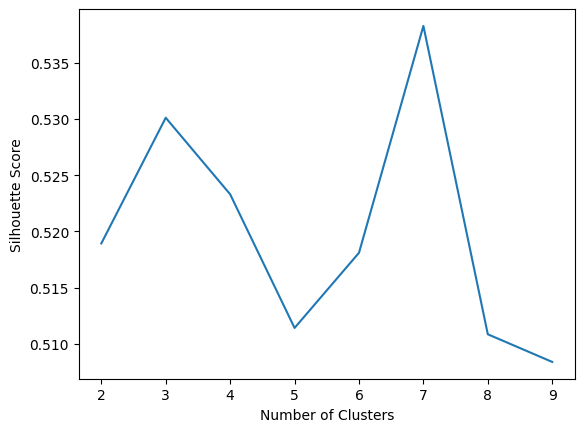

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
#assigning Beta column to X
X = df[['Beta']]
#testing number of cluster from 2 to 10 and collecting the silhouette
range_n_clusters = [2, 3, 4, 5, 6, 7, 8, 9]
scores = []
for n_clusters in range_n_clusters:
  agglom = AgglomerativeClustering(n_clusters=n_clusters)
  agglom.fit(X)
  labels = agglom.labels_
  scores.append(silhouette_score(X, labels))
#looking at the scores, and their average/mean
scores
average = sum(scores)/len(scores)
average
#graphing
plt.plot(range_n_clusters, scores)
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show

Cluster 1 has 269 observations
Cluster 2 has 232 observations


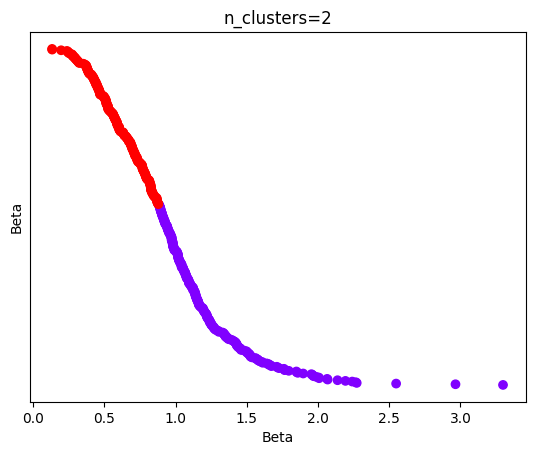

Cluster 1 has 79 observations
Cluster 2 has 232 observations
Cluster 3 has 190 observations


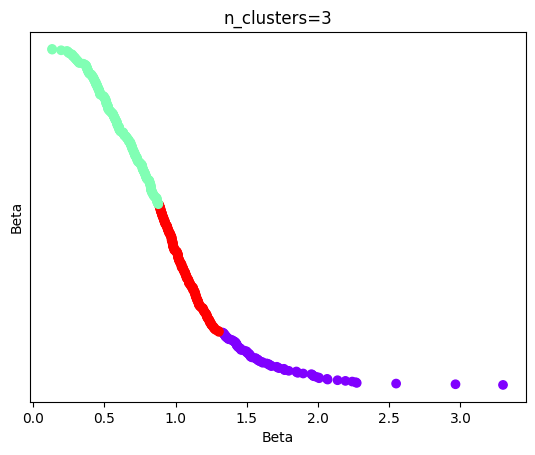

Cluster 1 has 232 observations
Cluster 2 has 28 observations
Cluster 3 has 190 observations
Cluster 4 has 51 observations


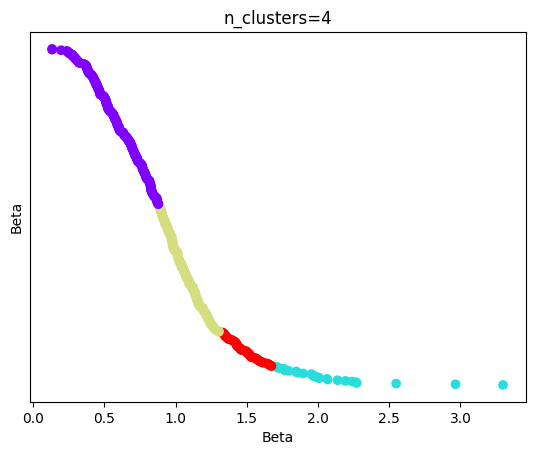

Cluster 1 has 28 observations
Cluster 2 has 124 observations
Cluster 3 has 190 observations
Cluster 4 has 51 observations
Cluster 5 has 108 observations


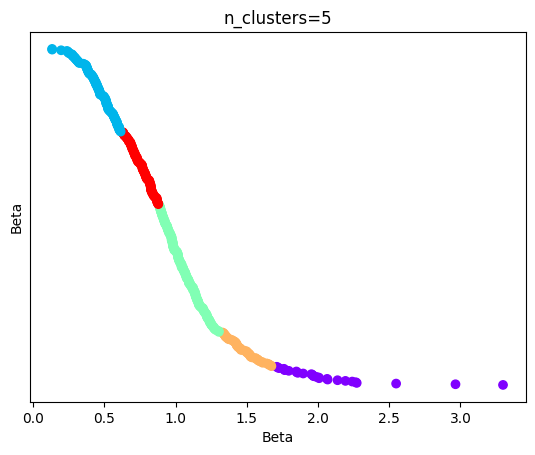

Cluster 1 has 190 observations
Cluster 2 has 124 observations
Cluster 3 has 26 observations
Cluster 4 has 51 observations
Cluster 5 has 108 observations
Cluster 6 has 2 observations


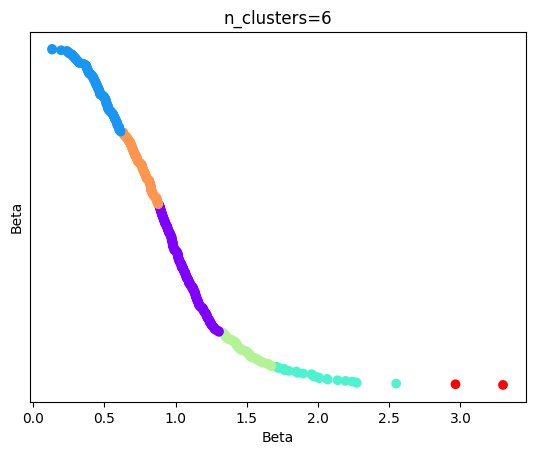

Cluster 1 has 124 observations
Cluster 2 has 108 observations
Cluster 3 has 26 observations
Cluster 4 has 51 observations
Cluster 5 has 123 observations
Cluster 6 has 2 observations
Cluster 7 has 67 observations


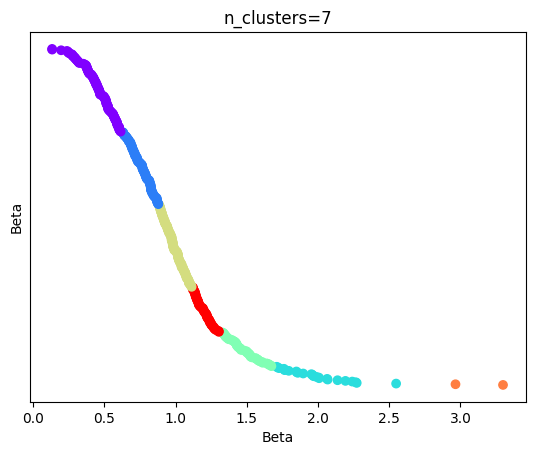

Cluster 1 has 26 observations
Cluster 2 has 108 observations
Cluster 3 has 69 observations
Cluster 4 has 51 observations
Cluster 5 has 123 observations
Cluster 6 has 2 observations
Cluster 7 has 67 observations
Cluster 8 has 55 observations


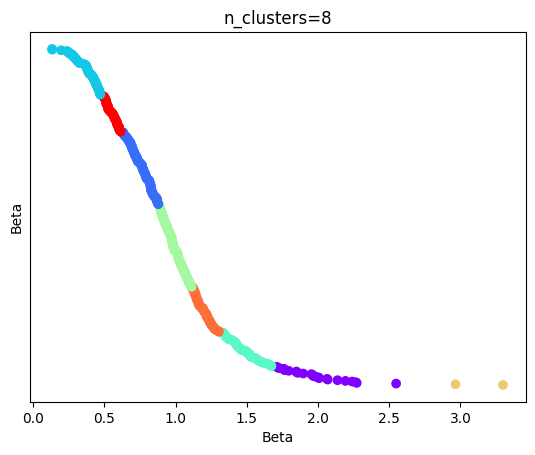

Cluster 1 has 108 observations
Cluster 2 has 123 observations
Cluster 3 has 69 observations
Cluster 4 has 51 observations
Cluster 5 has 18 observations
Cluster 6 has 2 observations
Cluster 7 has 67 observations
Cluster 8 has 55 observations
Cluster 9 has 8 observations


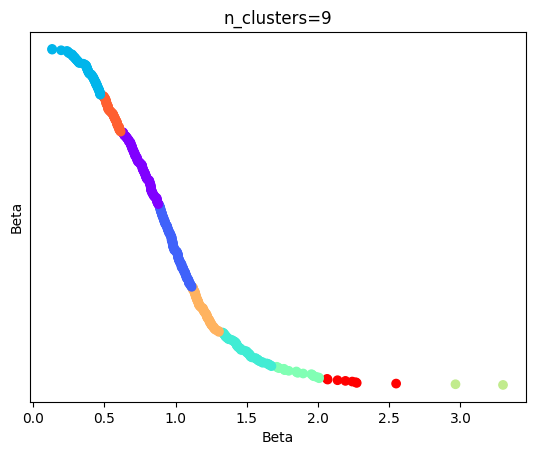

In [ ]:
import numpy as np
for n_clusters in range_n_clusters:
  model = AgglomerativeClustering(n_clusters=n_clusters)
  labels = model.fit_predict(X)
  plt.scatter(X, df['Ticker'], c=labels, cmap='rainbow')
  plt.xlabel('Beta')
  plt.ylabel('Beta')
  plt.title(f"n_clusters={n_clusters}")
  cluster_counts = np.bincount(labels)
  for i in range(n_clusters):
    print(f"Cluster {i+1} has {cluster_counts[i]} observations")
  plt.yticks([])
  plt.show()

In [ ]:
optimal_n_clusters = 5
agglom = AgglomerativeClustering(n_clusters=optimal_n_clusters)
cluster_labels = agglom.fit_predict(df[['Beta']])
df['Cluster'] = cluster_labels
df

,Ticker,Beta,Cluster
0,CVNA,3.298454,0
1,COIN,2.964902,0
2,XYZ,2.548173,0
3,NVDA,2.271536,0
4,APP,2.264945,0
...,...,...,...
496,LMT,0.244190,1
497,HRL,0.236923,1
498,SJM,0.196850,1
499,CPB,0.133844,1


/usr/local/lib/python3.12/dist-packages/seaborn/regression.py:598: UserWarning:

legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.



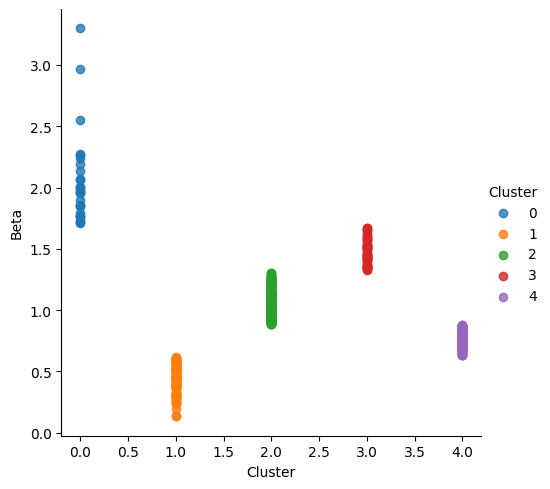

In [ ]:
import seaborn as sns
cluster4 = sns.lmplot(data=df, x='Cluster', y='Beta', hue='Cluster',
legend=True, legend_out=True);

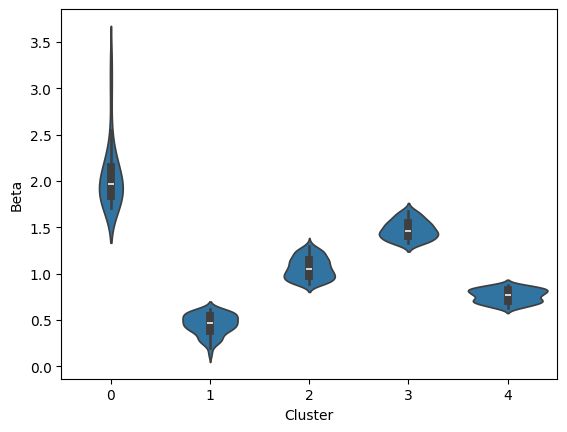

In [ ]:
sns.violinplot(x='Cluster', y='Beta', data=df)
plt.show()